# Published-image transfer case: BBBC050 3D nuclei

This exercise uses CC BY 3.0 BBBC050 mouse-embryo fluorescence stacks to ask a
measurement-design question: **what information changes when a 3D image is
reduced to two dimensions?** It does not reproduce the source study or make a
developmental claim.

Source: https://bbbc.broadinstitute.org/BBBC050
Publication: Tokuoka et al. (2020), https://doi.org/10.1038/s41540-020-00152-8

## Learning objectives

1. inspect stack dimensions and bit depth before analysis;
2. distinguish a central plane, mean projection and maximum projection;
3. quantify how projection choice changes foreground agreement and object count;
4. explain why a 2D projection cannot automatically operationalize a 3D volume.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import measure

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.segmentation import load_tiff_stack, project_stack
from src.sensitivity import SensitivityConfig, mask_iou, segment_with_config

DATA = ROOT / "data" / "external" / "BBBC050"
if not (DATA / "Images" / "train" / "Images").exists():
    raise FileNotFoundError(
        "BBBC050 is absent. Run: python scripts/download_bbbc050.py"
    )

## Declared teaching sample

We select three deposited training files from one embryo (`Emb01`). They are
used to expose projection sensitivity, not as independent biological replicates
and not to estimate change over developmental time.

In [2]:
names = ["Emb01_t001.tif", "Emb01_t251.tif", "Emb01_t501.tif"]
image_dir = DATA / "Images" / "train" / "Images"
truth_dir = DATA / "GroundTruth" / "train" / "GroundTruth_QCANet"

records = []
for name in names:
    stack = load_tiff_stack(image_dir / name)
    reference_stack = load_tiff_stack(truth_dir / name)
    records.append({"image_id": Path(name).stem, "stack": stack,
                    "reference_stack": reference_stack})

pd.DataFrame([{
    "image_id": row["image_id"], "shape_z_y_x": str(row["stack"].shape),
    "dtype": str(row["stack"].dtype), "minimum": int(row["stack"].min()),
    "maximum": int(row["stack"].max())
} for row in records])

,image_id,shape_z_y_x,dtype,minimum,maximum
0,Emb01_t001,"(51, 124, 127)",uint16,92,1369
1,Emb01_t251,"(51, 124, 127)",uint16,92,6339
2,Emb01_t501,"(51, 124, 127)",uint16,91,1147


## Compare explicit 2D operationalizations

The same Otsu/connected-component configuration is applied after each 2D
reduction. This isolates projection choice; it does not establish that the
segmentation configuration is optimal.

In [3]:
methods = ["central", "mean", "maximum"]
config = SensitivityConfig("otsu_components", 1.0, 12, "otsu", None, 8, 1)
results = []
views = {}

for row in records:
    for method in methods:
        image_2d = project_stack(row["stack"], method)
        if method == "central":
            reference_2d = row["reference_stack"][row["reference_stack"].shape[0] // 2] > 0
        else:
            reference_2d = row["reference_stack"].max(axis=0) > 0
        _, predicted_mask, predicted_labels, threshold = segment_with_config(image_2d, config)
        reference_labels = measure.label(reference_2d)
        views[(row["image_id"], method)] = (image_2d, predicted_labels, reference_labels)
        results.append({
            "image_id": row["image_id"], "projection": method,
            "threshold": threshold,
            "mask_iou_agreement": mask_iou(predicted_mask, reference_2d),
            "predicted_objects": int(predicted_labels.max()),
            "derived_reference_objects": int(reference_labels.max()),
            "predicted_foreground_fraction": float(predicted_mask.mean()),
            "reference_foreground_fraction": float(reference_2d.mean()),
        })

results_df = pd.DataFrame(results)
results_df.round(4)

,image_id,projection,threshold,mask_iou_agreement,predicted_objects,derived_reference_objects,predicted_foreground_fraction,reference_foreground_fraction
0,Emb01_t001,central,0.2402,0.4071,1,2,0.0174,0.0427
1,Emb01_t001,mean,0.2090,0.5442,2,1,0.0324,0.0596
2,Emb01_t001,maximum,0.2168,0.6060,2,1,0.0361,0.0596
3,Emb01_t251,central,0.2715,0.6717,2,4,0.0337,0.0501
4,Emb01_t251,mean,0.1504,0.5260,4,5,0.0433,0.0816
5,Emb01_t251,maximum,0.1230,0.5437,4,5,0.0451,0.0816
6,Emb01_t501,central,0.1777,0.6554,15,12,0.1106,0.1661
7,Emb01_t501,mean,0.1973,0.5587,14,7,0.1920,0.3437
8,Emb01_t501,maximum,0.1348,0.5716,18,7,0.1965,0.3437


In [4]:
results_df.groupby("projection", as_index=False).agg(
    mean_mask_iou_agreement=("mask_iou_agreement", "mean"),
    mean_predicted_objects=("predicted_objects", "mean"),
    mean_predicted_foreground_fraction=("predicted_foreground_fraction", "mean"),
).round(4)

,projection,mean_mask_iou_agreement,mean_predicted_objects,mean_predicted_foreground_fraction
0,central,0.5781,6.0000,0.0539
1,maximum,0.5737,8.0000,0.0926
2,mean,0.5429,6.6667,0.0893


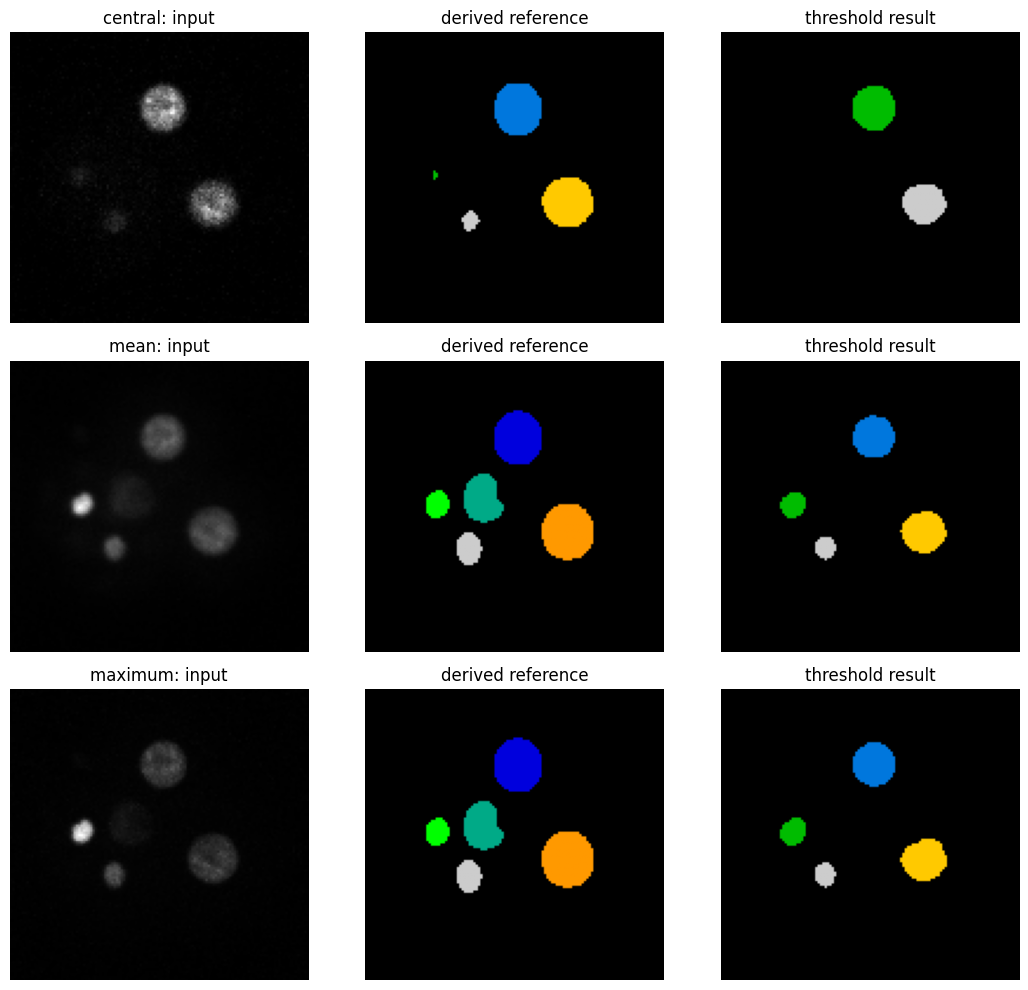

In [5]:
example_id = records[1]["image_id"]
fig, axes = plt.subplots(3, 3, figsize=(11, 10))
for row_index, method in enumerate(methods):
    image_2d, predicted, reference = views[(example_id, method)]
    axes[row_index, 0].imshow(image_2d, cmap="gray")
    axes[row_index, 0].set_title(f"{method}: input")
    axes[row_index, 1].imshow(reference, cmap="nipy_spectral")
    axes[row_index, 1].set_title("derived reference")
    axes[row_index, 2].imshow(predicted, cmap="nipy_spectral")
    axes[row_index, 2].set_title("threshold result")
for axis in axes.ravel():
    axis.axis("off")
plt.tight_layout()

## Interpretation boundary

Projection methods answer different questions. A central plane omits signal
outside one optical section; a maximum projection retains bright signal from
any plane but collapses depth and can merge objects; a mean projection weights
signal across the full stack and can suppress small bright structures.

Write a short answer: which projection best matches your intended construct,
and what three-dimensional information would still be lost? The acceptable
claim is that measurements vary with projection choice in these teaching files.
Do not infer embryo development, model accuracy, or biological mechanisms.